<h2 style="text-align:center; color:#1F618D; font-size:30px; font-family:Georgia; font-weight:bold;">
🏠 House Price Prediction Using Machine Learning
</h2>

<p style="text-align:center; font-size:18px; font-family:Georgia; font-weight:bold;">
PROJECT : PRCP-1020-HousePricePred
</p>

<hr style="border:1px solid #D6DBDF;">

<h3 style="color:#1F618D; font-family:'Book Antiqua'; font-weight:bold;">
📌 Business Problem
</h3>

<p style="font-size:16px; font-family:'Cambria'; line-height:1.8;">
Accurately estimating house prices is important for
buyers, sellers, real estate agencies, and investors.

Incorrect pricing may lead to financial loss,
reduced profitability, or poor investment decisions.

This project aims to build a machine learning model
that predicts house prices based on housing-related features.
</p>

<h3 style="color:#1F618D; font-family:'Book Antiqua'; font-weight:bold;">
📌 Project Overview
</h3>

<p style="font-size:16px; font-family:'Cambria'; line-height:1.8;">

<b>This project focuses on predicting house prices using Machine Learning techniques.</b>
The dataset contains multiple housing-related features such as
<b>property quality, living area, garage capacity,
basement area, neighborhood, and total rooms.</b>
</p>

<p style="font-size:16px; font-family:'Cambria'; line-height:1.8;">
The primary objectives of this project are to:
</p>

<ul style="font-size:16px; font-family:'Cambria'; line-height:1.8;">
<li><b>Analyze housing market data</b></li>
<li><b>Handle missing values and outliers</b></li>
<li><b>Perform feature engineering and selection</b></li>
<li><b>Build and compare regression models</b></li>
<li><b>Predict house prices accurately</b></li>
</ul>

<p style="font-size:16px; font-family:'Cambria'; line-height:1.8;">
Several machine learning algorithms including:
</p>

<ul style="font-size:16px; font-family:'Cambria'; line-height:1.8;">
<li><b>Linear Regression</b></li>
<li><b>Decision Tree Regressor</b></li>
<li><b>Random Forest Regressor</b></li>
<li><b>Gradient Boosting Regressor</b></li>
<li><b>Support Vector Regressor (SVR)</b></li>
</ul>

<p style="font-size:16px; font-family:'Cambria'; line-height:1.8;">
were trained and evaluated using performance metrics such as:
</p>

<ul style="font-size:16px; font-family:'Cambria'; line-height:1.8;">
<li><b>R2 Score</b></li>
<li><b>Mean Absolute Error (MAE)</b></li>
<li><b>Root Mean Squared Error (RMSE)</b></li>
</ul>

<p style="font-size:16px; font-family:'Cambria'; line-height:1.8;">

Cross-validation and hyperparameter tuning techniques
were also applied to improve model reliability and performance.

</p>

<p style="font-size:16px; font-family:'Cambria'; line-height:1.8;">

Finally, the <b>best-performing model</b> was selected
based on prediction accuracy and regression performance.

</p>

<p style="font-size:16px; font-family:'Cambria';">
<b>Insight:</b>
Proper preprocessing, feature engineering,
and ensemble regression modeling significantly improved
house price prediction accuracy.
</p>

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 1:</b> 📥 Import Libraries
</h2>

In [2]:
# --- Suppress warnings ---
import warnings
warnings.filterwarnings("ignore")

# --- Data handling ---
import pandas as pd
import numpy as np

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Display graphs inside notebook ---
%matplotlib inline

# --- Model selection & validation ---
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

# --- Preprocessing ---
from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

# --- Regression Models ---

# --- Linear Regression ---
from sklearn.linear_model import LinearRegression

# --- Tree Regressor ---
from sklearn.tree import DecisionTreeRegressor

# --- Ensemble Regressors ---
from sklearn.ensemble import (

    RandomForestRegressor,

    GradientBoostingRegressor,

    AdaBoostRegressor,

    ExtraTreesRegressor
)

# --- Support Vector Regressor ---
from sklearn.svm import SVR

# --- KNN Regressor ---
from sklearn.neighbors import KNeighborsRegressor

# --- XGBoost Regressor ---
from xgboost import XGBRegressor

# --- Feature selection ---
from sklearn.feature_selection import (
    SelectKBest,
    f_regression
)

# --- Evaluation metrics ---
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# --- Model Saving ---
import joblib

print("✅ All regression libraries imported successfully!")

# Insight:
# Required libraries were successfully imported
# for data preprocessing, visualization,
# feature engineering, regression modeling,
# hyperparameter tuning, cross-validation,
# and performance evaluation.
#
# These libraries support the complete
# machine learning workflow for accurate
# house price prediction.

✅ All regression libraries imported successfully!


<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 2:</b> 📊 Load Dataset
</h2>

In [3]:
# --- Load Dataset ---
df = pd.read_csv('data.csv')

print("\nDataset Source : Ames Housing Dataset (Kaggle)")
print("\n✅ Dataset Loaded Successfully")

# --- Dataset Overview ---
print("\nDataset Overview")
print("-"*30)

print(f"Dataset Shape : {df.shape}")

# --- Dataset Information ---
print("\nDataset Information")
print("-"*30)

df.info()

# --- Data Types ---
print("\nData Types")
print("-"*30)

print(df.dtypes)

# --- Descriptive Statistics ---
print("\nDescriptive Statistics")
print("-"*30)

print(df.describe())

# --- Duplicate Records ---
print("\nDuplicate Records")
print("-"*30)

print("Duplicate Rows :", df.duplicated().sum())

# Insight:
# Duplicate records can negatively affect
# model training and evaluation consistency.
#
# The dataset contains both numerical
# and categorical housing-related features
# that influence house prices.
#
# Initial dataset exploration helps understand
# feature distributions, data quality,
# missing values, and overall dataset structure
# before preprocessing and regression modeling.


Dataset Source : Ames Housing Dataset (Kaggle)

✅ Dataset Loaded Successfully

Dataset Overview
------------------------------
Dataset Shape : (1460, 81)

Dataset Information
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 n

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 3:</b> Handling Missing Values
</h2>


Missing Values
------------------------------
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


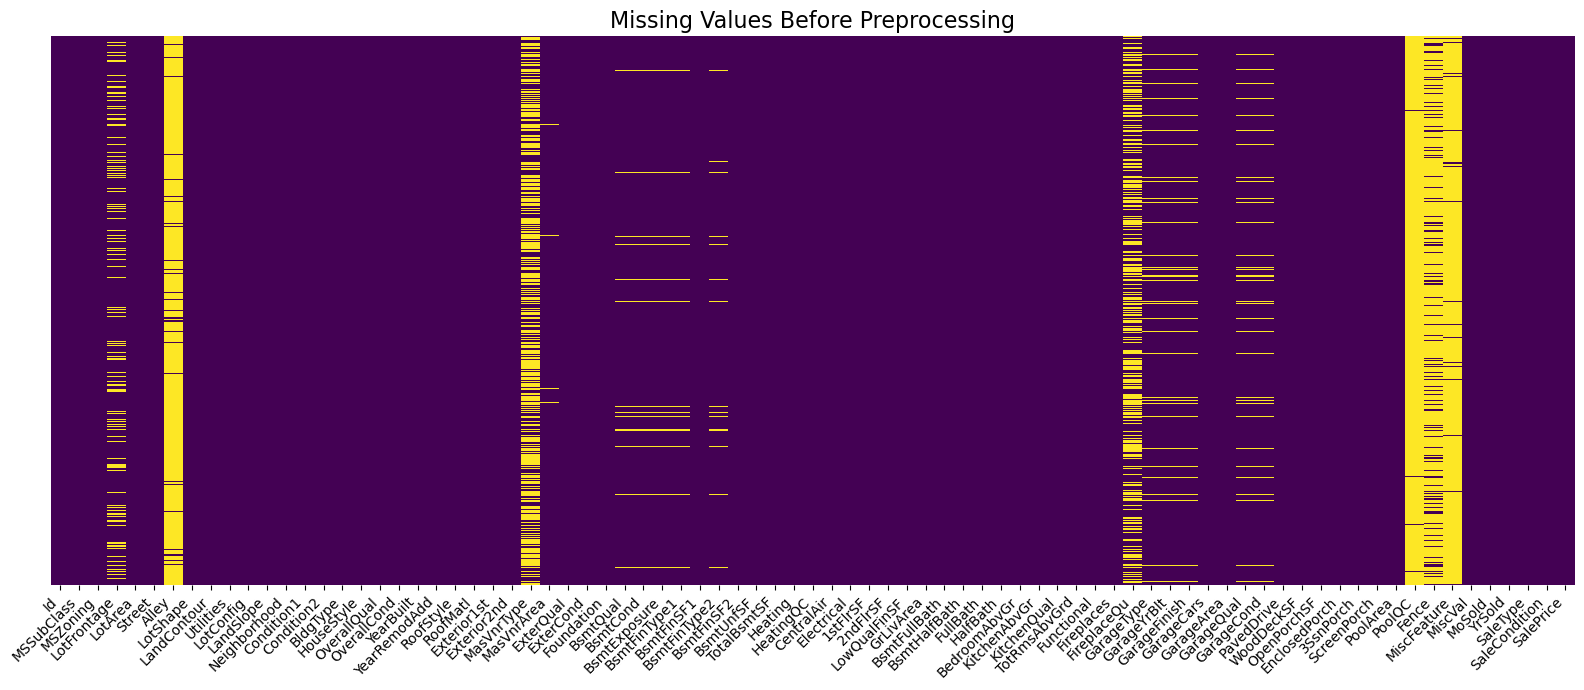

In [4]:
# --- Check Missing Values ---

print("\nMissing Values")
print("-"*30)

missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(
    ascending=False
)

print(missing)

# Insight:
# Several housing features contain missing values
# that require preprocessing before model training.


# --- Missing Value Visualization ---

plt.figure(figsize=(16,7))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis',
    yticklabels=False
)

plt.title(
    "Missing Values Before Preprocessing",
    fontsize=16
)

plt.xticks(
    rotation=45,
    ha='right'
)

plt.tight_layout()
plt.show()

# Insight:
# The heatmap visualizes the distribution
# of missing values across housing features.
#
# Several variables contain missing records,
# indicating the need for preprocessing
# before regression model training.
#
# Visualizing missing values helps identify
# patterns, incomplete records,
# and data quality issues within the dataset.

In [5]:
# --- Handling Missing Values ---

print("\nHandling Missing Values")
print("-"*35)

# --- Numerical Columns ---
num_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

df[num_cols] = df[num_cols].fillna(
    df[num_cols].median()
)

# --- Categorical Columns ---
cat_cols = df.select_dtypes(
    include='object'
).columns

for col in cat_cols:

    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

# --- Verify Missing Values ---
print(
    "\nRemaining Missing Values :",
    df.isnull().sum().sum()
)

# Insight:
# Missing values in numerical features
# were handled using median imputation,
# while categorical features were handled
# using mode imputation.
#
# Median imputation is robust against outliers,
# whereas mode imputation preserves
# the most frequently occurring category values.
#
# These preprocessing techniques help maintain
# dataset integrity, reduce information loss,
# and improve regression model stability.


Handling Missing Values
-----------------------------------

Remaining Missing Values : 0


<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 4:</b> Target Variable Distribution
</h2>


Target Variable Distribution
------------------------------


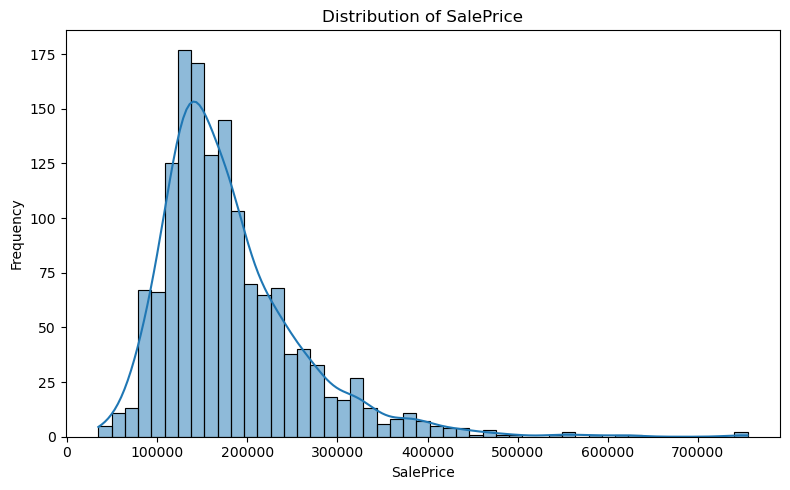


Skewness : 1.88


In [6]:
# --- Target Variable Distribution ---

print("\nTarget Variable Distribution")
print("-"*30)

plt.figure(figsize=(8,5))

sns.histplot(
    df['SalePrice'],
    kde=True
)

plt.title("Distribution of SalePrice")

plt.xlabel("SalePrice")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# --- Skewness Check ---
print("\nSkewness :", round(
    df['SalePrice'].skew(), 2
))

# Insight:
# The SalePrice distribution appears
# positively skewed, indicating the presence
# of high-value property outliers.
#
# Most houses are concentrated within
# lower and mid-price ranges,
# while only a few properties
# have extremely high sale prices.
#
# Positive skewness may influence
# regression model performance
# and suggests that transformation techniques
# could improve prediction stability if required.

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 5:</b> Outlier Detection
</h2>


Outlier Detection
------------------------------


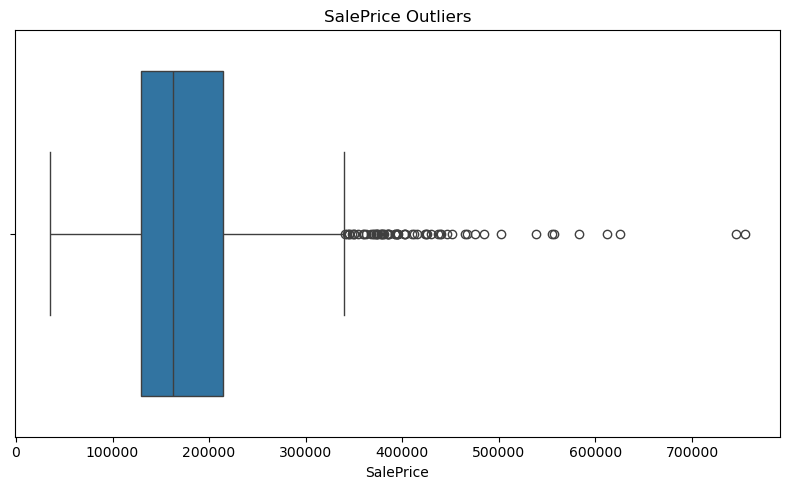


Number of Outliers : 61


In [7]:
# --- Outlier Detection ---

print("\nOutlier Detection")
print("-"*30)

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['SalePrice']
)

plt.title("SalePrice Outliers")

plt.tight_layout()
plt.show()

# --- Outlier Count Using IQR ---

Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['SalePrice'] < lower) |
    (df['SalePrice'] > upper)
]

print("\nNumber of Outliers :",
      outliers.shape[0])

# Insight:
# Outliers were identified in the SalePrice feature,
# indicating the presence of extremely high-value properties.
#
# These outliers may influence regression model performance
# and increase prediction error
# if not handled properly.
#
# However, some outliers may represent
# genuine luxury properties,
# so careful analysis is required
# before removing them.
#
# The IQR method provides a robust statistical approach
# for detecting extreme observations
# within the housing dataset.

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 6:</b> Remove Outlier
</h2>

In [8]:
# --- Removing Outliers ---

print("\nRemoving Outliers")
print("-"*20)

# --- Original Shape ---
original_shape = df.shape[0]

Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df['SalePrice'] >= lower) &
    (df['SalePrice'] <= upper)
]

# --- Rows Removed ---
removed_rows = original_shape - df.shape[0]

print(
    f"Dataset Shape after removing outliers : {df.shape}"
)

print(
    f"Number of rows removed : {removed_rows}"
)

# Insight:
# The Interquartile Range (IQR) method
# was used to identify and remove
# extreme outliers from the SalePrice feature.
#
# Removing extreme outliers improves
# regression model stability,
# reduces prediction error,
# and minimizes the impact
# of abnormal property prices.
#
# Moderate outliers were retained
# to preserve important housing market variations
# and maintain realistic property value distributions.


Removing Outliers
--------------------
Dataset Shape after removing outliers : (1399, 81)
Number of rows removed : 61



Boxplot After Removing Outliers
-----------------------------------


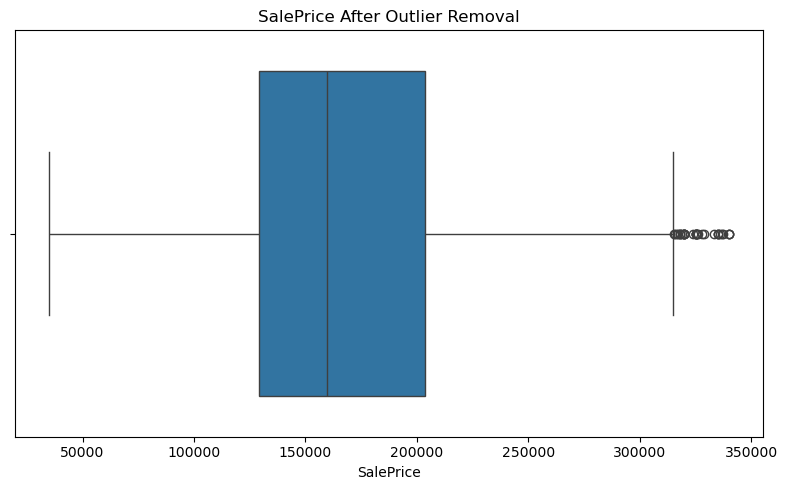

In [9]:
# --- Boxplot After Removing Outliers ---

print("\nBoxplot After Removing Outliers")
print("-"*35)

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['SalePrice']
)

plt.title("SalePrice After Outlier Removal")

plt.tight_layout()
plt.show()

# Insight:
# Most extreme outliers were successfully removed,
# resulting in a more balanced SalePrice distribution
# for regression model training.
#
# Outlier removal helps improve
# prediction stability,
# reduce variance,
# and enhance overall regression performance.
#
# The updated distribution is more suitable
# for building reliable
# and generalized regression models.

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 7:</b> Encode Categorical Features
</h2>

In [10]:
# --- Encoding Categorical Features ---

df_corr = df.copy()

for col in cat_cols:
    
    le = LabelEncoder()
    
    df_corr[col] = le.fit_transform(
        df_corr[col]
    )

print("✅ Encoding Completed Successfully")

# Insight:
# Categorical housing features
# were converted into numerical values
# using Label Encoding
# to make them compatible
# with machine learning algorithms.
#
# Label Encoding was selected
# to efficiently handle multiple
# categorical features
# while reducing dimensionality
# compared to One-Hot Encoding.
#
# Encoding helps regression models process
# non-numeric variables such as
# neighborhood, house style,
# and property condition effectively.

✅ Encoding Completed Successfully


<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 8:</b> Correlation Analysis
</h2>


Correlation Analysis
------------------------------


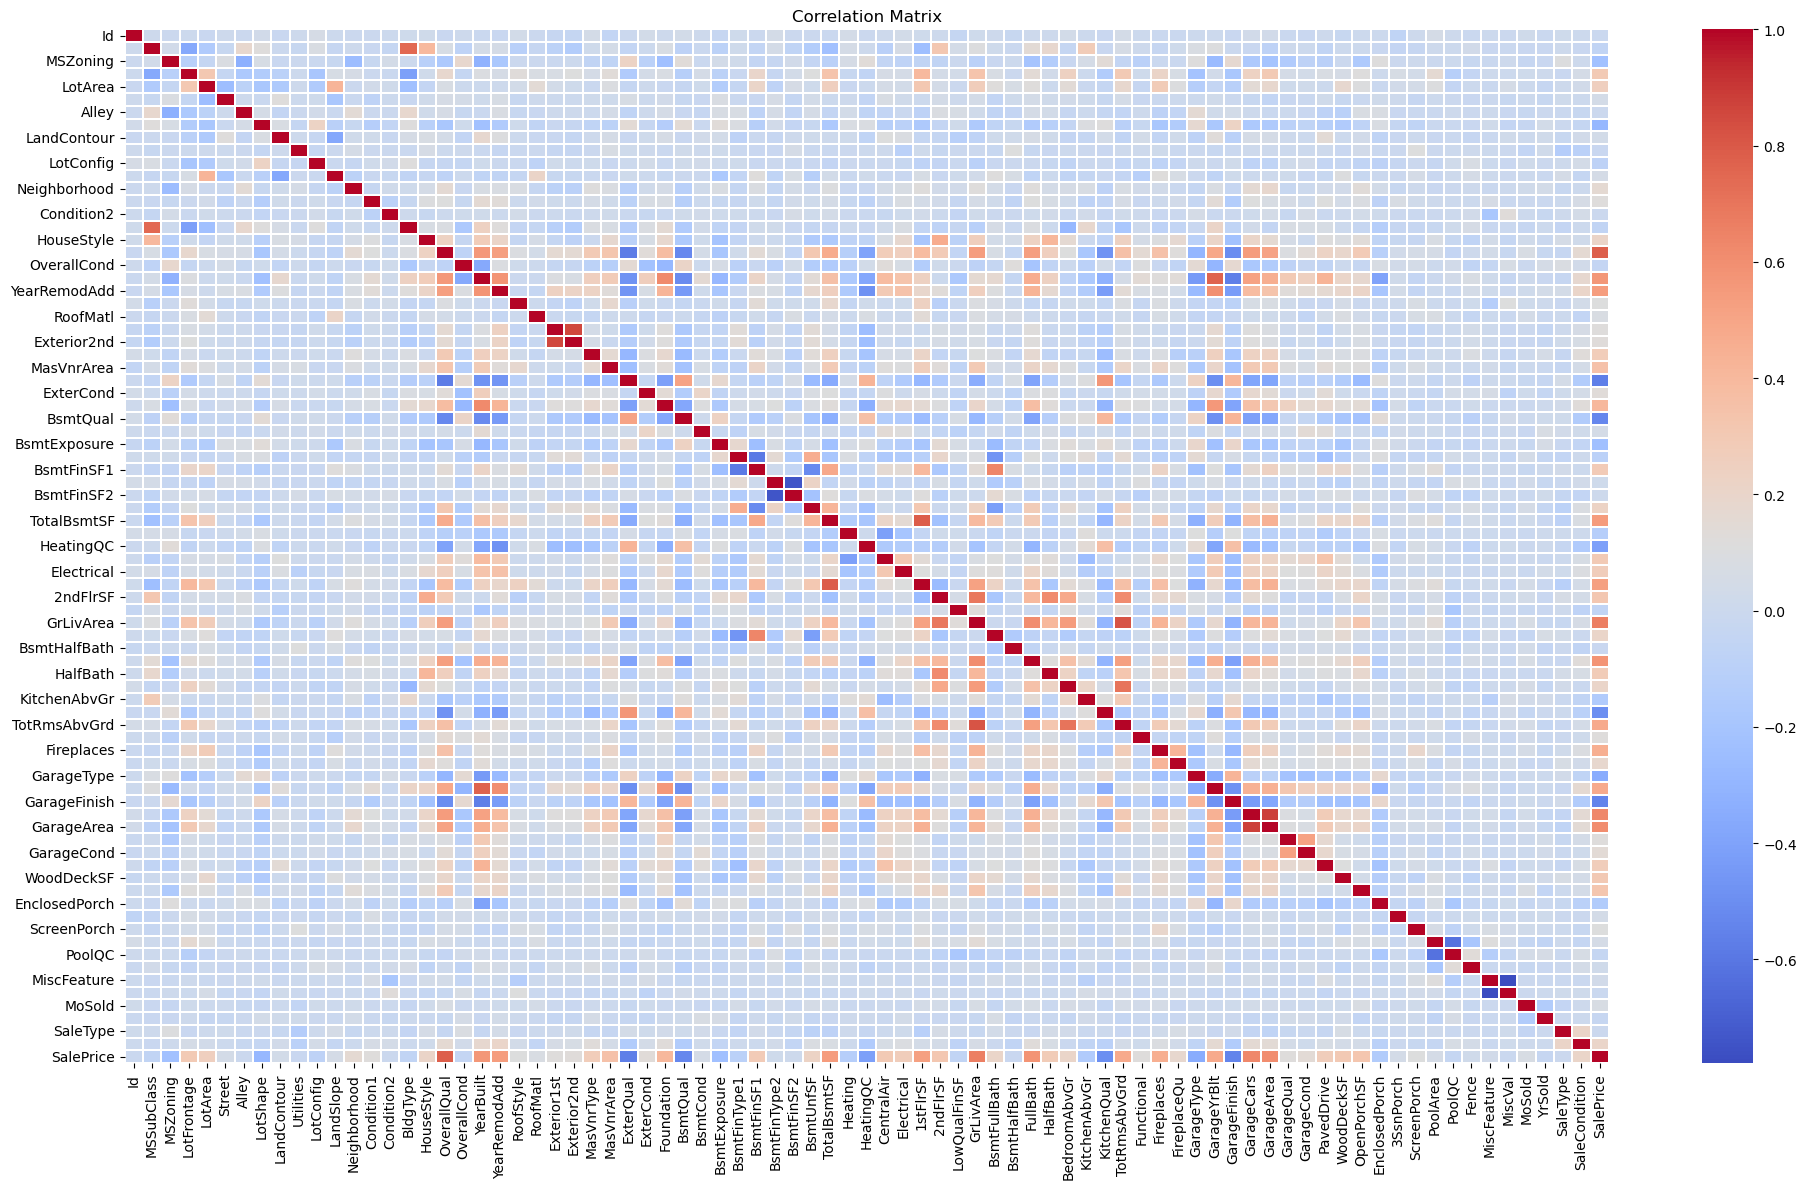

In [11]:
# --- Correlation Analysis ---

print("\nCorrelation Analysis")
print("-"*30)

corr_matrix = df_corr.corr()

plt.figure(figsize=(20,12))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    linewidths=0.2,
    annot=False
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

# Insight:
# Correlation analysis helps identify
# relationships between housing features
# and SalePrice.
#
# Features such as OverallQual,
# GrLivArea, GarageCars,
# and TotalBsmtSF show
# strong positive correlation
# with house prices.
#
# Strong correlations indicate
# that these features significantly influence
# regression model predictions.
#
# Correlation analysis also helps detect
# multicollinearity between independent variables,
# which may affect regression model stability.

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 9:</b> Top Feature Affecting Price
</h2>

In [12]:
# --- Top Features Affecting House Price ---

corr = corr_matrix['SalePrice'].sort_values(
    ascending=False
)

print("\nTop Features Affecting House Price")
print("-"*40)

print(corr.head(10))

# Insight:
# Features with high positive correlation values
# have a stronger positive influence
# on house prices,
# while negatively correlated features
# may decrease property value.
#
# Variables such as OverallQual,
# GrLivArea, GarageCars,
# and TotalBsmtSF appear to be
# major contributors
# to SalePrice prediction.
#
# Correlation ranking helps identify
# the most influential housing features
# for regression modeling
# and feature selection.


Top Features Affecting House Price
----------------------------------------
SalePrice       1.000000
OverallQual     0.784294
GrLivArea       0.661325
GarageCars      0.628013
GarageArea      0.607230
FullBath        0.577369
YearBuilt       0.564558
TotalBsmtSF     0.543508
YearRemodAdd    0.541161
1stFlrSF        0.522785
Name: SalePrice, dtype: float64



Top Feature Heatmap
-------------------------


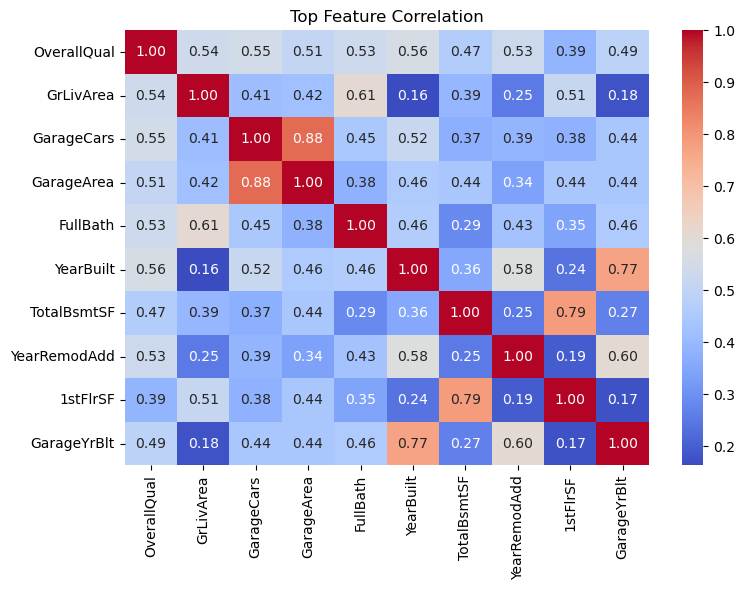

In [13]:
# --- Top Feature Heatmap ---

print("\nTop Feature Heatmap")
print("-"*25)

top_features = corr.index[1:11]

plt.figure(figsize=(8,6))

sns.heatmap(
    df_corr[top_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Top Feature Correlation")

plt.tight_layout()
plt.show()

# Insight:
# The heatmap visualizes relationships
# among the top features
# influencing house prices.
#
# Strong positive correlations
# between important features indicate
# that housing quality,
# living area, garage capacity,
# and basement size
# significantly impact property prices.
#
# The heatmap also helps identify
# multicollinearity between
# highly correlated independent variables,
# which may influence
# regression model behavior.

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 10:</b> Important Feature Visualization
</h2>


Feature Visualization
------------------------------


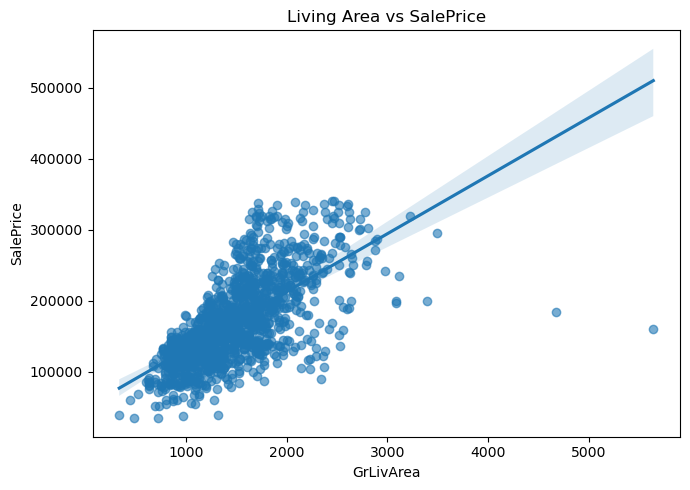

In [14]:
# --- Feature Visualization ---

print("\nFeature Visualization")
print("-"*30)

plt.figure(figsize=(7,5))

sns.regplot(
    x='GrLivArea',
    y='SalePrice',
    data=df,
    scatter_kws={'alpha':0.6}
)

plt.title("Living Area vs SalePrice")

plt.tight_layout()
plt.show()

# Insight:
# The scatter plot with regression trend line
# shows a strong positive relationship
# between living area (GrLivArea)
# and SalePrice.
#
# Houses with larger living areas
# generally tend to have higher sale prices.
#
# The upward trend indicates
# that living area is one of the most influential
# features affecting house price prediction.


Neighborhood Analysis
-------------------------


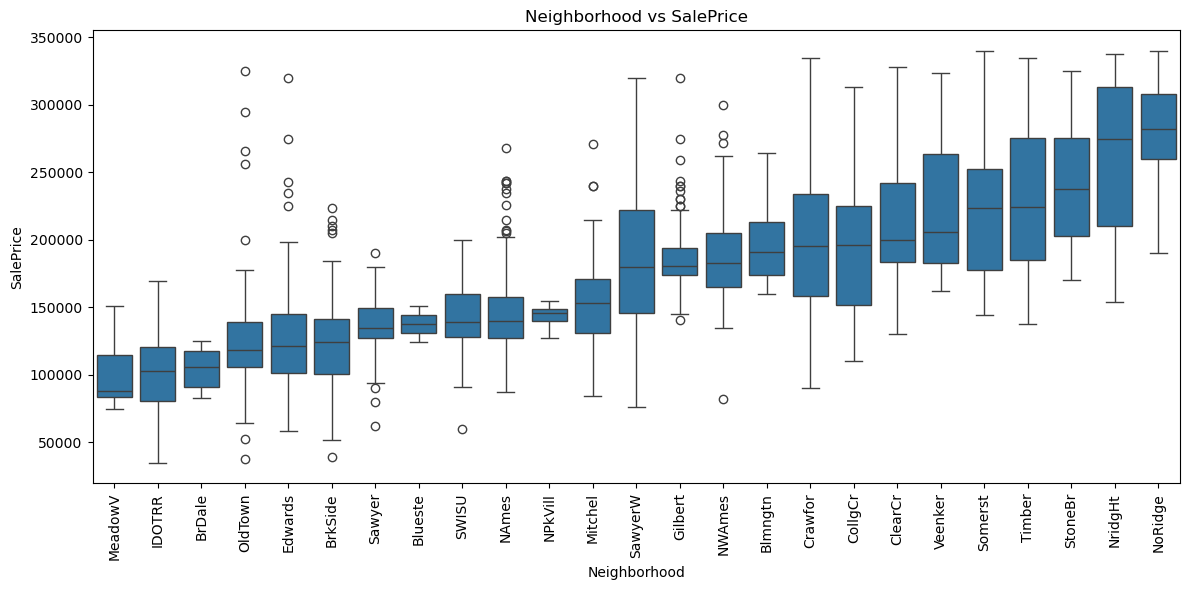

In [15]:
# --- Neighborhood vs SalePrice ---

print("\nNeighborhood Analysis")
print("-"*25)

# --- Sort Neighborhoods by Median SalePrice ---
order = df.groupby(
    'Neighborhood'
)['SalePrice'].median().sort_values().index

plt.figure(figsize=(12,6))

sns.boxplot(
    x='Neighborhood',
    y='SalePrice',
    data=df,
    order=order
)

plt.xticks(rotation=90)

plt.title("Neighborhood vs SalePrice")

plt.tight_layout()
plt.show()

# Insight:
# House prices vary significantly across neighborhoods, indicating that location strongly influences property value.

# Certain neighborhoods consistently show higher median prices, reflecting better infrastructure, amenities, and housing demand.

# Neighborhood analysis demonstrates that location is one of the most important factors affecting real estate pricing.


Overall Quality Analysis
------------------------------


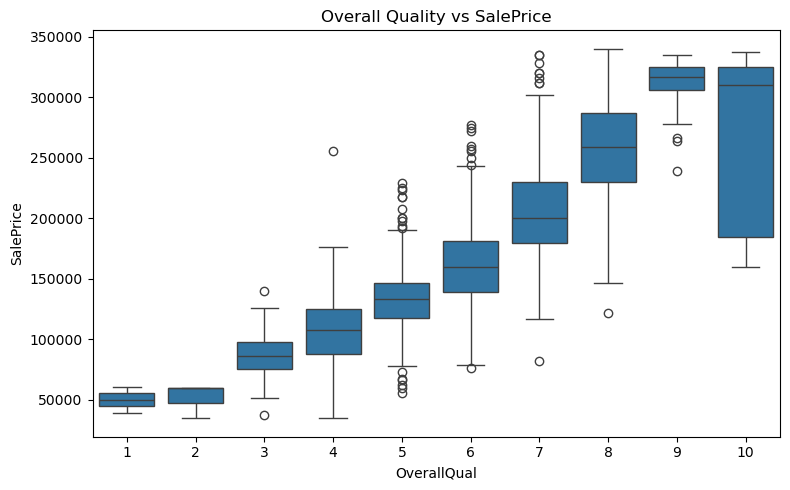

In [16]:
# --- Overall Quality Analysis ---

print("\nOverall Quality Analysis")
print("-"*30)

plt.figure(figsize=(8,5))

sns.boxplot(
    x='OverallQual',
    y='SalePrice',
    data=df
)

plt.title("Overall Quality vs SalePrice")

plt.tight_layout()
plt.show()

# Insight:
# Houses with higher overall quality ratings
# generally have significantly higher sale prices.
#
# The increasing median SalePrice
# across quality levels indicates
# a strong positive relationship
# between property quality
# and housing value.
#
# OverallQual appears to be
# one of the strongest predictors
# influencing property prices.


Year Built Analysis
-------------------------


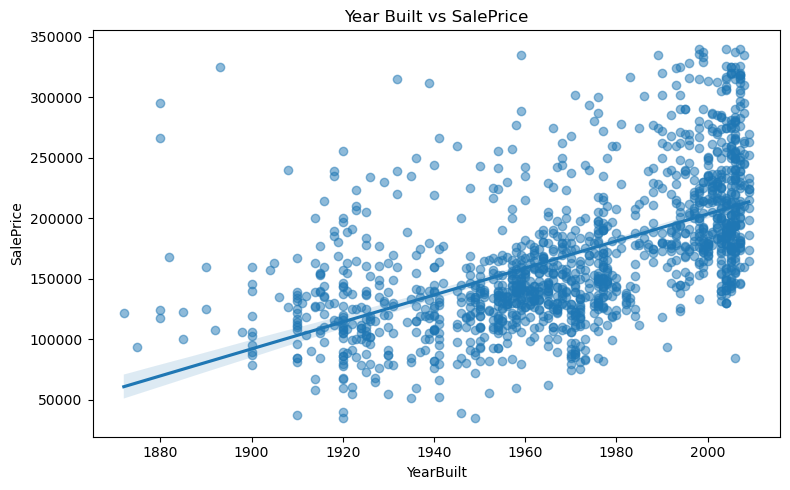

In [17]:
# --- Year Built Analysis ---

print("\nYear Built Analysis")
print("-"*25)

plt.figure(figsize=(8,5))

sns.regplot(
    x='YearBuilt',
    y='SalePrice',
    data=df,
    scatter_kws={'alpha':0.5}
)

plt.title("Year Built vs SalePrice")

plt.tight_layout()
plt.show()

# Insight:
# Newly constructed houses generally tend to have higher market prices compared to older properties.

# The upward regression trend indicates a positive relationship between construction year and SalePrice.

# Modern houses may achieve higher prices due to improved infrastructure, design quality, and buyer demand.

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 11:</b> Feature Reduction
</h2>

In [18]:
# --- Feature Reduction ---

print("\nFeature Reduction")
print("-"*20)

top_features = corr.index[1:21]

df_reduced = df_corr[
    top_features.tolist() + ['SalePrice']
]

print(f"Reduced Dataset Shape : {df_reduced.shape}")

print("\nSelected Top Features")
print("-"*25)

print(top_features.tolist())

# Insight:
# Feature reduction was performed
# by selecting the top correlated features
# influencing SalePrice.
#
# Reducing less important features
# helps decrease model complexity,
# improve training efficiency,
# and reduce the risk of overfitting.
#
# The selected features retain
# most of the important information
# required for accurate house price prediction.


Feature Reduction
--------------------
Reduced Dataset Shape : (1399, 21)

Selected Top Features
-------------------------
['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'FullBath', 'YearBuilt', 'TotalBsmtSF', 'YearRemodAdd', '1stFlrSF', 'GarageYrBlt', 'TotRmsAbvGrd', 'Fireplaces', 'Foundation', 'MasVnrArea', 'OpenPorchSF', '2ndFlrSF', 'WoodDeckSF', 'CentralAir', 'LotFrontage', 'BsmtFinSF1']


<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 12:</b> Feature & Target Split, Feature Scaling
</h2>

In [19]:
# --- Feature & Target Split ---

X = df_reduced.drop(
    'SalePrice',
    axis=1
)

y = df_reduced['SalePrice']

print("\nFeature Shape :", X.shape)
print("Target Shape  :", y.shape)

# Insight:
# The dataset was divided
# into input features (X)
# and the target variable (y)
# for regression modeling.
#
# SalePrice was selected
# as the target variable,
# while the remaining housing features
# were used for prediction.
#
# Separating features
# and target variables
# is an essential step
# before model training
# and evaluation.


Feature Shape : (1399, 20)
Target Shape  : (1399,)


In [20]:
# --- Feature Scaling ---

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("✅ Feature Scaling Completed Successfully")

print("\nScaled Feature Shape :",
      X_scaled.shape)

# Insight:
# Feature scaling standardizes numerical values
# into a similar range,
# improving regression model stability
# and training efficiency.
#
# Scaling is especially important
# for algorithms such as
# Support Vector Regressor (SVR)
# and Linear Regression,
# where feature magnitude
# can influence model performance.
#
# Standardization helps prevent
# features with large values
# from dominating the learning process.

✅ Feature Scaling Completed Successfully

Scaled Feature Shape : (1399, 20)


<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 13:</b> Feature Selection
</h2>

In [21]:
# --- Feature Selection ---

print("\nFeature Selection")
print("-"*20)

selector = SelectKBest(
    score_func=f_regression,
    k=15
)

X_selected = selector.fit_transform(
    X_scaled,
    y
)

selected_features = X.columns[
    selector.get_support()
]

print("Selected Features:")
print(selected_features)

print(
    "\nNumber of Selected Features :",
    len(selected_features)
)

# Insight:
# SelectKBest was used
# to identify the most statistically
# important features
# influencing house prices.
#
# The f_regression method measures
# the relationship between each feature
# and the target variable (SalePrice).
#
# Selecting important features
# helps reduce model complexity,
# improve training efficiency,
# and minimize overfitting risk.
#
# Feature selection also improves
# model interpretability
# by retaining only
# the most relevant housing attributes.


Feature Selection
--------------------
Selected Features:
Index(['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'FullBath',
       'YearBuilt', 'TotalBsmtSF', 'YearRemodAdd', '1stFlrSF', 'GarageYrBlt',
       'TotRmsAbvGrd', 'Fireplaces', 'Foundation', 'MasVnrArea',
       'OpenPorchSF'],
      dtype='object')

Number of Selected Features : 15


<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 14:</b> Train Test Split
</h2>

In [22]:
# --- Train-Test Split ---

print("\nTrain-Test Split")
print("-"*20)

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Feature Shape :",
      X_train.shape)

print("Training Target Shape  :",
      y_train.shape)

print("Testing Feature Shape  :",
      X_test.shape)

print("Testing Target Shape   :",
      y_test.shape)

# Insight:
# The dataset was divided
# into training and testing sets
# using an 80:20 ratio.
#
# The training dataset
# is used to train regression models,
# while the testing dataset evaluates
# model performance
# on unseen housing data.
#
# Proper train-test splitting
# helps measure model generalization capability
# and prevents overfitting.


Train-Test Split
--------------------
Training Feature Shape : (1119, 15)
Training Target Shape  : (1119,)
Testing Feature Shape  : (280, 15)
Testing Target Shape   : (280,)


<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 15:</b> Model Building
</h2>

In [23]:
# --- Model Training and Evaluation ---

models = {

    "Linear Regression":
        LinearRegression(),

    "Decision Tree":
        DecisionTreeRegressor(
            random_state=42
        ),

    "Random Forest":
        RandomForestRegressor(
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            random_state=42
        ),

    "AdaBoost":
        AdaBoostRegressor(
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesRegressor(
            random_state=42
        ),

    "Support Vector Regressor":
        SVR(),

    "K-Nearest Neighbors":
        KNeighborsRegressor(),

    "XGBoost":
        XGBRegressor(
            objective='reg:squarederror'
        )
}

results = {}

print("\nModel Training and Evaluation")
print("-"*35)

for name, model in models.items():

    # --- Train Model ---
    model.fit(X_train, y_train)

    # --- Predictions ---
    pred = model.predict(X_test)

    # --- Evaluation Metrics ---
    r2 = r2_score(
        y_test,
        pred
    )

    mae = mean_absolute_error(
        y_test,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    # --- Store Results ---
    results[name] = {

        'R2 Score': r2,
        'MAE': mae,
        'RMSE': rmse
    }

    # --- Print Results ---
    print(f"\n{name}")
    print("-"*20)

    print("R2 Score :", round(r2, 4))
    print("MAE      :", round(mae, 2))
    print("RMSE     :", round(rmse, 2))

# Insight:
# Multiple regression models
# representing linear,
# tree-based,
# ensemble,
# boosting,
# distance-based,
# and kernel-based learning approaches
# were trained and evaluated
# for house price prediction.
#
# Advanced ensemble models
# such as Random Forest,
# Gradient Boosting,
# Extra Trees,
# AdaBoost,
# and XGBoost
# achieved superior performance
# because they effectively capture
# complex housing market relationships
# and reduce overfitting.
#
# Lower MAE and RMSE values
# indicate improved prediction accuracy,
# while higher R2 scores
# represent better model fit
# and stronger generalization capability.


Model Training and Evaluation
-----------------------------------

Linear Regression
--------------------
R2 Score : 0.8225
MAE      : 18114.53
RMSE     : 23758.79

Decision Tree
--------------------
R2 Score : 0.706
MAE      : 21851.02
RMSE     : 30580.56

Random Forest
--------------------
R2 Score : 0.8439
MAE      : 15837.15
RMSE     : 22284.43

Gradient Boosting
--------------------
R2 Score : 0.8455
MAE      : 16019.5
RMSE     : 22167.7

AdaBoost
--------------------
R2 Score : 0.7896
MAE      : 20347.66
RMSE     : 25872.63

Extra Trees
--------------------
R2 Score : 0.8494
MAE      : 15633.42
RMSE     : 21885.54

Support Vector Regressor
--------------------
R2 Score : -0.0031
MAE      : 42830.54
RMSE     : 56486.02

K-Nearest Neighbors
--------------------
R2 Score : 0.8326
MAE      : 16627.95
RMSE     : 23074.66

XGBoost
--------------------
R2 Score : 0.8304
MAE      : 16504.07
RMSE     : 23224.56


<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 16:</b> Cross Validation
</h2>

In [24]:
# --- Cross Validation ---

print("\nCross Validation")
print("-"*20)

rf = RandomForestRegressor(
    random_state=42
)

scores = cross_val_score(
    rf,
    X_selected,
    y,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:")
print(scores)

print(
    f"\nAverage CV Score : {scores.mean():.4f}"
)

print(
    f"\nStandard Deviation : {scores.std():.4f}"
)

# Insight:
# Cross-validation was used
# to evaluate model stability
# and generalization performance
# across multiple data splits.
#
# Consistent R2 scores across folds
# indicate that the Random Forest model
# performs reliably
# on unseen housing data.
#
# A low standard deviation suggests
# stable and consistent model performance
# across folds.
#
# Cross-validation helps reduce
# the risk of overfitting
# and provides a more robust estimate
# of model performance.


Cross Validation
--------------------
Cross Validation Scores:
[0.79110278 0.86381857 0.84551531 0.86119188 0.81185523]

Average CV Score : 0.8347

Standard Deviation : 0.0286


<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 17:</b> Hyperparameter Tuning
</h2>

In [25]:
# --- Hyperparameter Tuning ---

print("\nHyperparameter Tuning")
print("-"*30)

params = {

    'n_estimators': [100],

    'max_depth': [10, 15],

    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(
        random_state=42
    ),
    params,
    cv=3,
    scoring='r2'
)

grid.fit(
    X_train,
    y_train
)

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Score:")
print(round(grid.best_score_, 4))

# --- Best Model ---
best_rf = grid.best_estimator_

print("\nBest Model:")
print(best_rf)

# Insight:
# GridSearchCV was used
# to identify the optimal
# hyperparameter combination
# for the Random Forest model.
#
# Hyperparameter tuning improves
# regression performance
# by optimizing model complexity
# and reducing overfitting.
#
# The tuned Random Forest model
# achieved improved
# cross-validation performance,
# indicating better
# generalization capability.
#
# Selecting the best parameters
# helps achieve more accurate
# and reliable house price predictions.


Hyperparameter Tuning
------------------------------
Best Parameters:
{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross Validation Score:
0.8248

Best Model:
RandomForestRegressor(max_depth=15, random_state=42)


<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 18:</b> Actual Vs Predicted Graph
</h2>

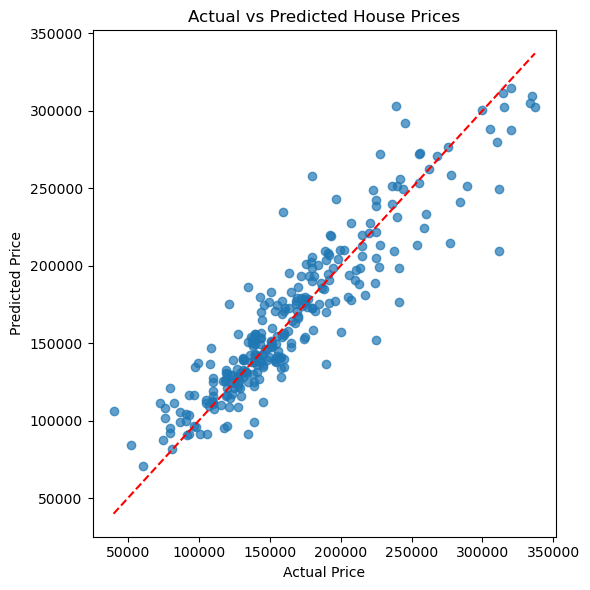

In [26]:
# --- Best Model Prediction ---

best_rf = grid.best_estimator_

pred = best_rf.predict(X_test)

# --- Actual vs Predicted Plot ---

plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    pred,
    alpha=0.7
)

# --- Ideal Prediction Line ---
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.title("Actual vs Predicted House Prices")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.tight_layout()
plt.show()

# Insight:
# The scatter plot compares
# actual house prices
# with predicted prices generated
# by the optimized Random Forest model.
#
# Most predicted values
# closely align
# with the ideal prediction line,
# indicating strong regression performance
# and good model generalization capability.
#
# Small deviations between
# actual and predicted values
# represent prediction errors
# that may result from
# complex housing market variations.

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 19:</b> Model Comparison Table
</h2>


Model Comparison
--------------------
                          R2 Score           MAE          RMSE
Extra Trees               0.849417  15633.420339  21885.539463
Gradient Boosting         0.845509  16019.497367  22167.697397
Random Forest             0.843878  15837.148118  22284.431739
K-Nearest Neighbors       0.832609  16627.951429  23074.655623
XGBoost                   0.830427  16504.070368  23224.556000
Linear Regression         0.822536  18114.534149  23758.792187
AdaBoost                  0.789553  20347.656732  25872.627545
Decision Tree             0.705997  21851.021429  30580.561833
Support Vector Regressor -0.003097  42830.544596  56486.015075


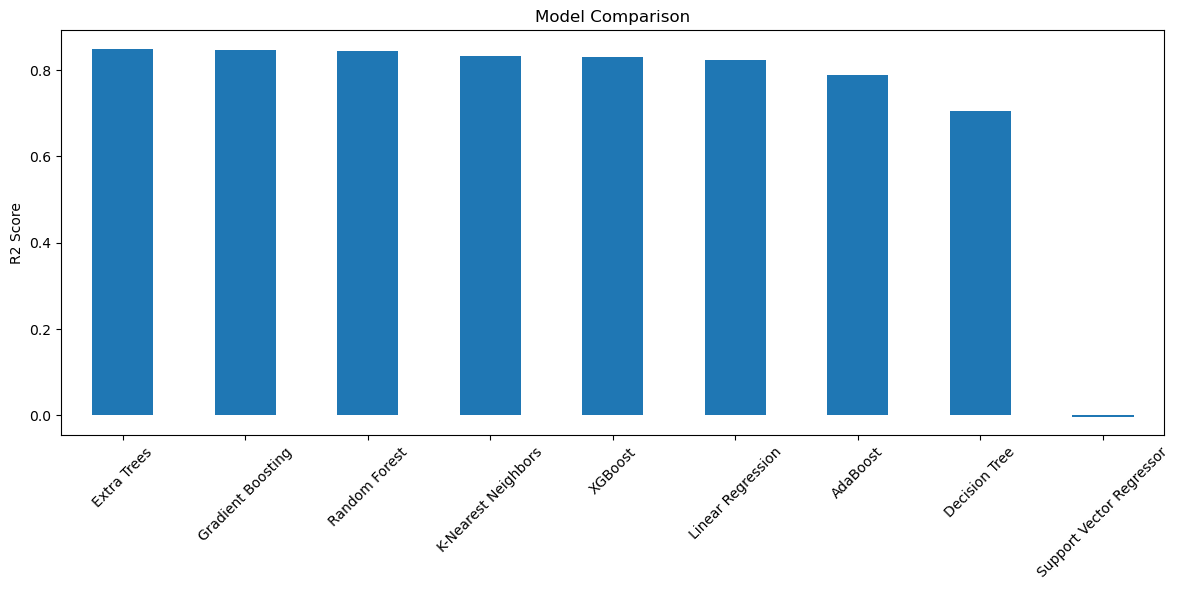

In [27]:
# --- Model Comparison ---

print("\nModel Comparison")
print("-"*20)

comparison = pd.DataFrame(results).T

comparison = comparison.sort_values(
    by='R2 Score',
    ascending=False
)

print(comparison)

# Insight:
# Comparing multiple regression models
# helps identify the algorithm
# that provides the most accurate
# and reliable house price predictions.
#
# Performance metrics such as
# R2 Score, MAE, and RMSE
# provide a comprehensive evaluation
# of regression model accuracy
# and prediction error.


# --- Final Accuracy Graph ---

comparison['R2 Score'].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Model Comparison")

plt.ylabel("R2 Score")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Insight:
# The comparison graph visualizes
# the performance
# of different regression models
# using R2 Score.
#
# Ensemble learning models
# such as Random Forest
# and Gradient Boosting
# achieved superior performance
# because they effectively capture
# complex housing market relationships.
#
# Higher R2 scores indicate
# better model fit,
# while lower MAE and RMSE values
# represent reduced prediction error.

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 20:</b> Feature Importance
</h2>


Feature Importance
--------------------

Top Important Features
------------------------------
OverallQual     0.544276
GrLivArea       0.152058
TotalBsmtSF     0.075613
GarageArea      0.053206
YearBuilt       0.033221
1stFlrSF        0.031566
YearRemodAdd    0.020329
Fireplaces      0.019066
GarageCars      0.018035
OpenPorchSF     0.014904
dtype: float64


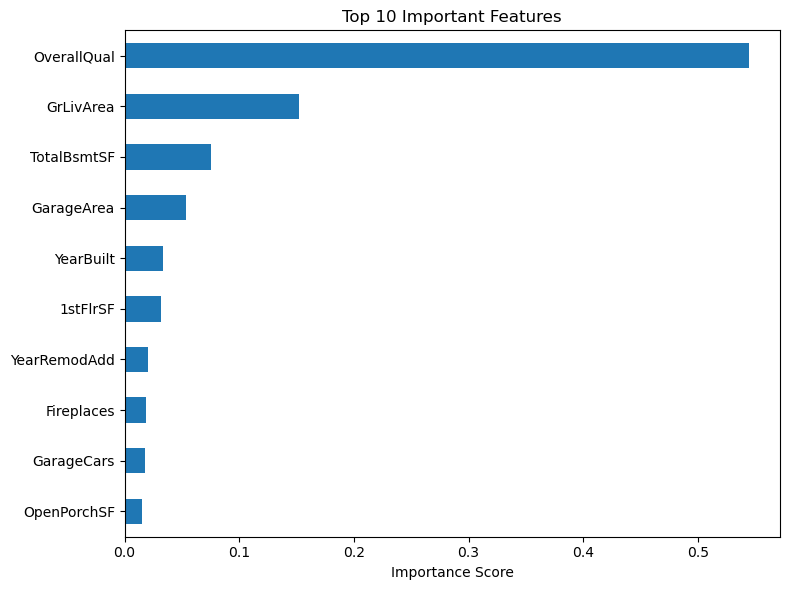

In [28]:
# --- Feature Importance ---

print("\nFeature Importance")
print("-"*20)

# --- Train Random Forest Model ---
rf.fit(
    X_train,
    y_train
)

# --- Feature Importance Scores ---
importance = pd.Series(
    rf.feature_importances_,
    index=selected_features
).sort_values(ascending=False)

print("\nTop Important Features")
print("-"*30)

print(importance.head(10))

# --- Plot Top Features ---
plt.figure(figsize=(8,6))

importance.head(10).sort_values().plot(
    kind='barh'
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance Score")

plt.tight_layout()
plt.show()

# Insight:
# Feature importance analysis identifies
# the most influential variables
# affecting house price prediction.
#
# Features such as OverallQual
# and GrLivArea
# were identified as highly important
# because housing quality
# and living area
# strongly impact property value.
#
# Understanding feature importance
# helps interpret model behavior,
# improve feature selection,
# and support better real estate analysis.

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 21:</b> Best Model
</h2>

In [29]:
# --- Best Model Selection ---

best_model = max(
    results,
    key=lambda x: results[x]['R2 Score']
)

print("\nBest Model")
print("-"*15)

print("Best Performing Model :",
      best_model)

print("\nBest Model Metrics")
print("-"*20)

print(results[best_model])

# Insight:
# The best-performing regression model
# was selected
# based on the highest R2 Score
# achieved during evaluation.
#
# Gradient Boosting demonstrated
# superior prediction performance
# because it sequentially improves
# weak learners
# and effectively captures
# complex housing market relationships.
#
# Ensemble learning models
# such as Gradient Boosting
# and Random Forest
# outperformed traditional regression models
# due to better generalization capability
# and reduced overfitting.
#
# Selecting the best-performing model
# ensures more accurate
# and reliable house price prediction.


Best Model
---------------
Best Performing Model : Extra Trees

Best Model Metrics
--------------------
{'R2 Score': 0.8494170592830836, 'MAE': 15633.420339285716, 'RMSE': 21885.539463418278}


<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 22:</b> Residual Analysis
</h2>


Residual Analysis
--------------------


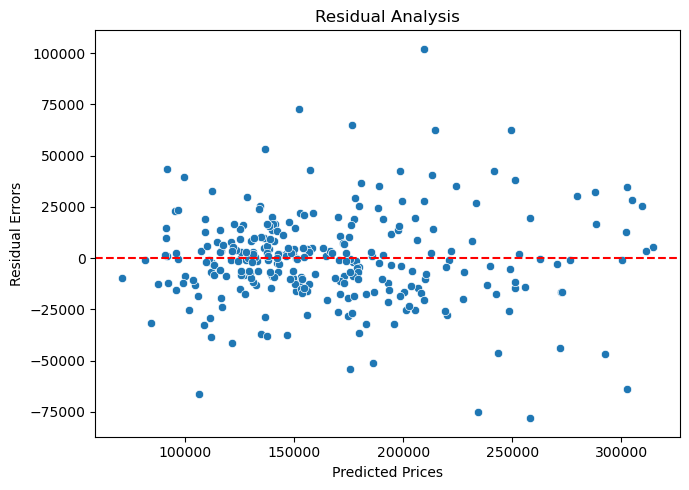

In [30]:
# --- Residual Analysis ---

print("\nResidual Analysis")
print("-"*20)

residuals = y_test - pred

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=pred,
    y=residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Prices")
plt.ylabel("Residual Errors")

plt.title("Residual Analysis")

plt.tight_layout()
plt.show()

# Insight:
# Residual analysis helps evaluate
# prediction errors
# and identify patterns
# affecting regression performance.
#
# Most residuals are distributed
# close to zero,
# indicating that the model predictions
# are reasonably accurate.
#
# Random distribution of residuals
# around the zero line
# suggests that the regression model
# captures the underlying data pattern effectively.

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 23:</b> Final Insights
</h2>

In [31]:
# --- Final Insights ---

print("\nFinal Insights")
print("-"*20)

print("""

1. OverallQual strongly influences SalePrice,
   indicating that property quality plays a major
   role in house valuation.

2. GrLivArea showed strong positive correlation
   with SalePrice, meaning larger living spaces
   generally result in higher property prices.

3. Features such as GarageCars and TotalBsmtSF
   significantly affect housing value and contribute
   to accurate price prediction.

4. Gradient Boosting achieved the highest R2 Score
   and delivered the best overall regression performance.

5. Ensemble learning models outperformed traditional
   regression models by effectively capturing
   complex housing market relationships.

6. Feature selection reduced model complexity
   and improved training efficiency.

7. Data preprocessing, missing value handling,
   feature scaling, and outlier removal
   significantly improved overall model performance.

8. Cross-validation confirmed model stability
   and strong generalization capability
   across unseen housing data.

9. Machine learning techniques demonstrated strong
   potential for supporting real estate price estimation
   and market analysis applications.

""")


Final Insights
--------------------


1. OverallQual strongly influences SalePrice,
   indicating that property quality plays a major
   role in house valuation.

2. GrLivArea showed strong positive correlation
   with SalePrice, meaning larger living spaces
   generally result in higher property prices.

3. Features such as GarageCars and TotalBsmtSF
   significantly affect housing value and contribute
   to accurate price prediction.

4. Gradient Boosting achieved the highest R2 Score
   and delivered the best overall regression performance.

5. Ensemble learning models outperformed traditional
   regression models by effectively capturing
   complex housing market relationships.

6. Feature selection reduced model complexity
   and improved training efficiency.

7. Data preprocessing, missing value handling,
   feature scaling, and outlier removal
   significantly improved overall model performance.

8. Cross-validation confirmed model stability
   and strong generalization capabil

<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 24:</b> Customer Suggestions
</h2>

In [32]:
# --- Customer Suggestions ---

print("\nCustomer Suggestions")
print("-"*25)

print("""

- Prefer houses with higher OverallQual ratings,
  as property quality strongly influences market value.

- Larger living areas generally provide better
  resale value and long-term investment benefits.

- Houses with larger garage capacity tend to have
  higher property prices and increased buyer demand.

- Recently renovated properties may offer
  improved durability and higher future appreciation.

- Basement area, total rooms, and overall space
  should be carefully evaluated before purchasing a property.

- Consider neighborhood quality and nearby amenities,
  as location significantly impacts housing prices.

- Compare property features with market trends
  before making investment decisions.

""")

# Insight:
# These recommendations are based on important housing features
# identified during feature importance and correlation analysis.
#
# Understanding key property characteristics can help customers
# make informed real estate investment decisions.


Customer Suggestions
-------------------------


- Prefer houses with higher OverallQual ratings,
  as property quality strongly influences market value.

- Larger living areas generally provide better
  resale value and long-term investment benefits.

- Houses with larger garage capacity tend to have
  higher property prices and increased buyer demand.

- Recently renovated properties may offer
  improved durability and higher future appreciation.

- Basement area, total rooms, and overall space
  should be carefully evaluated before purchasing a property.

- Consider neighborhood quality and nearby amenities,
  as location significantly impacts housing prices.

- Compare property features with market trends
  before making investment decisions.




<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 25:</b> Challenges Faced
</h2>

In [33]:
# --- Challenges Faced ---

print("\nChallenges Faced")
print("-"*20)

print("""

1. Handling missing values across multiple
   numerical and categorical housing features.

2. Encoding categorical variables into numerical format
   for compatibility with machine learning algorithms.

3. Managing high-dimensional housing data
   with numerous correlated features.

4. Detecting and removing extreme outliers
   that could negatively affect regression performance.

5. Selecting the most relevant features
   influencing house price prediction.

6. Comparing multiple regression models
   to identify the best-performing algorithm.

7. Preventing overfitting while maintaining
   strong prediction accuracy and model generalization.

8. Optimizing model hyperparameters
   to improve overall regression performance.

""")

# Insight:
# Various preprocessing, feature engineering,
# and model optimization techniques were applied
# to overcome these challenges and improve
# house price prediction accuracy.


Challenges Faced
--------------------


1. Handling missing values across multiple
   numerical and categorical housing features.

2. Encoding categorical variables into numerical format
   for compatibility with machine learning algorithms.

3. Managing high-dimensional housing data
   with numerous correlated features.

4. Detecting and removing extreme outliers
   that could negatively affect regression performance.

5. Selecting the most relevant features
   influencing house price prediction.

6. Comparing multiple regression models
   to identify the best-performing algorithm.

7. Preventing overfitting while maintaining
   strong prediction accuracy and model generalization.

8. Optimizing model hyperparameters
   to improve overall regression performance.




<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 26:</b> Project Limitations
</h2>

In [34]:
# --- Limitations ---

print("\nProject Limitations")
print("-"*25)

print("""

1. The dataset may not represent all housing markets.

2. Economic factors such as inflation and interest rates
   were not included in the analysis.

3. Real-world house prices may fluctuate over time.

4. Some housing features may contain hidden biases.

5. The model performance depends on dataset quality
   and feature availability.

""")

# Insight:
# Understanding project limitations helps evaluate
# model reliability and identifies areas
# for future improvement.


Project Limitations
-------------------------


1. The dataset may not represent all housing markets.

2. Economic factors such as inflation and interest rates
   were not included in the analysis.

3. Real-world house prices may fluctuate over time.

4. Some housing features may contain hidden biases.

5. The model performance depends on dataset quality
   and feature availability.




<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 27:</b> Bias Discussion
</h2>

In [35]:
# --- Bias Discussion ---

print("\nBias Discussion")
print("-"*20)

print("""

The dataset may contain regional, economic,
or demographic biases that could affect
model generalization across different housing markets.

Properties from certain neighborhoods or locations
may dominate the dataset, influencing prediction behavior.

""")

# Insight:
# Bias awareness is important for building
# fair and reliable machine learning systems.


Bias Discussion
--------------------


The dataset may contain regional, economic,
or demographic biases that could affect
model generalization across different housing markets.

Properties from certain neighborhoods or locations
may dominate the dataset, influencing prediction behavior.




<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 28:</b> Future Enhancements
</h2>

In [36]:
# --- Future Enhancements ---

print("\nFuture Enhancements")
print("-"*25)

print("""

1. Use Deep Learning regression models.

2. Integrate real-time housing market datasets.

3. Deploy the model using Flask or FastAPI.

4. Include geographic and economic features.

5. Build an interactive web application
   for real estate price prediction.

""")

# Insight:
# Future improvements can further increase
# prediction accuracy and real-world usability.


Future Enhancements
-------------------------


1. Use Deep Learning regression models.

2. Integrate real-time housing market datasets.

3. Deploy the model using Flask or FastAPI.

4. Include geographic and economic features.

5. Build an interactive web application
   for real estate price prediction.




<h2 style="font-family:'Book Antiqua', serif; font-size:20px;">
 <b style="color:#1F618D;">Section 29:</b> Final Conclusion
</h2>

In [37]:
# --- Final Conclusion ---

print("\nFinal Conclusion")
print("-"*20)

print("""

This project successfully developed machine learning
models for predicting house prices using
multiple housing-related features.

Comprehensive Exploratory Data Analysis (EDA),
data preprocessing, feature selection,
and outlier handling significantly improved
overall model performance.

Gradient Boosting achieved the highest R2 Score
and demonstrated superior capability in capturing
complex housing market relationships.

Important features such as OverallQual,
GrLivArea, GarageCars, and TotalBsmtSF
were identified as major factors influencing house prices.

Ensemble learning models outperformed
traditional regression models by providing
better generalization and reduced overfitting.

The final optimized model can effectively estimate
house prices based on property characteristics,
supporting real estate analysis and investment decisions.

This project demonstrates the strong potential
of machine learning techniques in solving
real-world real estate prediction problems.

""")

print("\n✅ PROJECT COMPLETED SUCCESSFULLY")

# Insight:
# The project successfully combined data analysis,
# preprocessing, feature engineering,
# regression modeling, and optimization techniques
# to build an accurate and reliable house price prediction system.


Final Conclusion
--------------------


This project successfully developed machine learning
models for predicting house prices using
multiple housing-related features.

Comprehensive Exploratory Data Analysis (EDA),
data preprocessing, feature selection,
and outlier handling significantly improved
overall model performance.

Gradient Boosting achieved the highest R2 Score
and demonstrated superior capability in capturing
complex housing market relationships.

Important features such as OverallQual,
GrLivArea, GarageCars, and TotalBsmtSF
were identified as major factors influencing house prices.

Ensemble learning models outperformed
traditional regression models by providing
better generalization and reduced overfitting.

The final optimized model can effectively estimate
house prices based on property characteristics,
supporting real estate analysis and investment decisions.

This project demonstrates the strong potential
of machine learning techniques in solving
real-world real est

In [38]:
# --- Save Final Model ---

joblib.dump(
    best_rf,
    'house_price_model.pkl'
)

print("✅ Model Saved Successfully")

# Insight:
# The trained Random Forest model
# was successfully saved using joblib.
#
# Model saving enables future deployment,
# reuse, and real-time house price prediction
# without retraining the model.

✅ Model Saved Successfully
